In [1]:
# Loading the dataset using pandas

import pandas as pd

df = pd.read_csv('customer_shopping_behavior.csv')

In [2]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [4]:
# Summary statistics using .describe()
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [5]:
# Checking if missing data or null values are present in the dataset

df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [2]:
# Imputing missing values in Review Rating column with the median rating of the product category

df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [7]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [3]:
# Renaming columns according to snake casing for better readability and documentation

df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [9]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [4]:
# create a new column age_group
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels = labels)

In [11]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [12]:
# create new column purchase_frequency_days

frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [13]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [14]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [15]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [16]:
# Dropping promo code used column

df = df.drop('promo_code_used', axis=1)

In [17]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='str')

## Code for MySQL

In [ ]:
!pip install pymysql sqlalchemy python-dotenv

In [24]:
!pip install mysql-connector-python sqlalchemy

   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
    --------------------------------------- 0.3/17.7 MB ? eta -:--:--
   - -------------------------------------- 0.8/17.7 MB 1.9 MB/s eta 0:00:09
   -- ------------------------------------- 1.3/17.7 MB 2.3 MB/s eta 0:00:08
   --- ------------------------------------ 1.6/17.7 MB 2.0 MB/s eta 0:00:09
   ---- ----------------------------------- 2.1/17.7 MB 2.1 MB/s eta 0:00:08
   ---- ----------------------------------- 2.1/17.7 MB 2.1 MB/s eta 0:00:08
   ----- ---------------------------------- 2.6/17.7 MB 1.8 MB/s eta 0:00:09
   ------- -------------------------------- 3.1/17.7 MB 1.9 MB/s eta 0:00:08
   -------- ------------------------------- 3.7/17.7 MB 2.0 MB/s eta 0:00:08
   -------- ------------------------------- 3.9/17.7 MB 1.9 MB/s eta 0:00:08
   --------- ------------------------------ 4.2/17.7 MB 2.0 MB/s eta 0:00:07
   ----------- -----

In [28]:
!pip install pymysql

In [ ]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus

load_dotenv()

username = os.getenv("MYSQL_USER")
password = os.getenv("MYSQL_PASSWORD")
host = os.getenv("MYSQL_HOST", "localhost")
port = os.getenv("MYSQL_PORT", "3306")

auth_url = f"mysql+pymysql://{username}:{quote_plus(password)}@{host}:{port}/"
check_engine = create_engine(auth_url)

with check_engine.connect() as conn:
    print("Connected to MySQL server on localhost.")
    print("Current user info:")
    result = conn.execute(text("SELECT USER(), CURRENT_USER();"))
    for row in result:
        print(row)

    print("\nAvailable databases:")
    result = conn.execute(text("SHOW DATABASES;"))
    databases = [row[0] for row in result]
    print(databases)

    expected_db = "customer_behavior_db"
    if expected_db in databases:
        print(f"\nDatabase '{expected_db}' exists.")
    else:
        print(f"\nDatabase '{expected_db}' does not exist.")
        print("Create it in MySQL Workbench or update the database name if needed.")

Connected to MySQL server on localhost.
Current user info:
('root@localhost', 'root@localhost')

Available databases:
['customer_behavior_db', 'information_schema', 'mysql', 'performance_schema', 'sakila', 'sys', 'world']

Database 'customer_behavior_db' exists.


In [ ]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
from urllib.parse import quote_plus

load_dotenv()

# MySQL connection
username = os.getenv("MYSQL_USER")
password = os.getenv("MYSQL_PASSWORD")
host = os.getenv("MYSQL_HOST", "localhost")
port = os.getenv("MYSQL_PORT", "3306")
database = os.getenv("MYSQL_DATABASE", "customer_behavior_db")

password_quoted = quote_plus(password)
engine = create_engine(f"mysql+pymysql://{username}:{password_quoted}@{host}:{port}/{database}")

# Write DataFrame to MySQL
table_name = "customer"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

# Read back sample
pd.read_sql("SELECT * FROM customer LIMIT 5;", engine)

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle-aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle-aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle-aged,365


## Visualizations

**Figure 8.1: Customer Behavior Dashboard overview showing the KPI numbers and the Subscription Pie Chart**

[Insert Figure 8.1 here]

**Figure 8.2: Revenue by Age Group Bar Chart**

[Insert Figure 8.2 here]

C:\Users\prave\AppData\Local\Temp\ipykernel_11280\1031764989.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


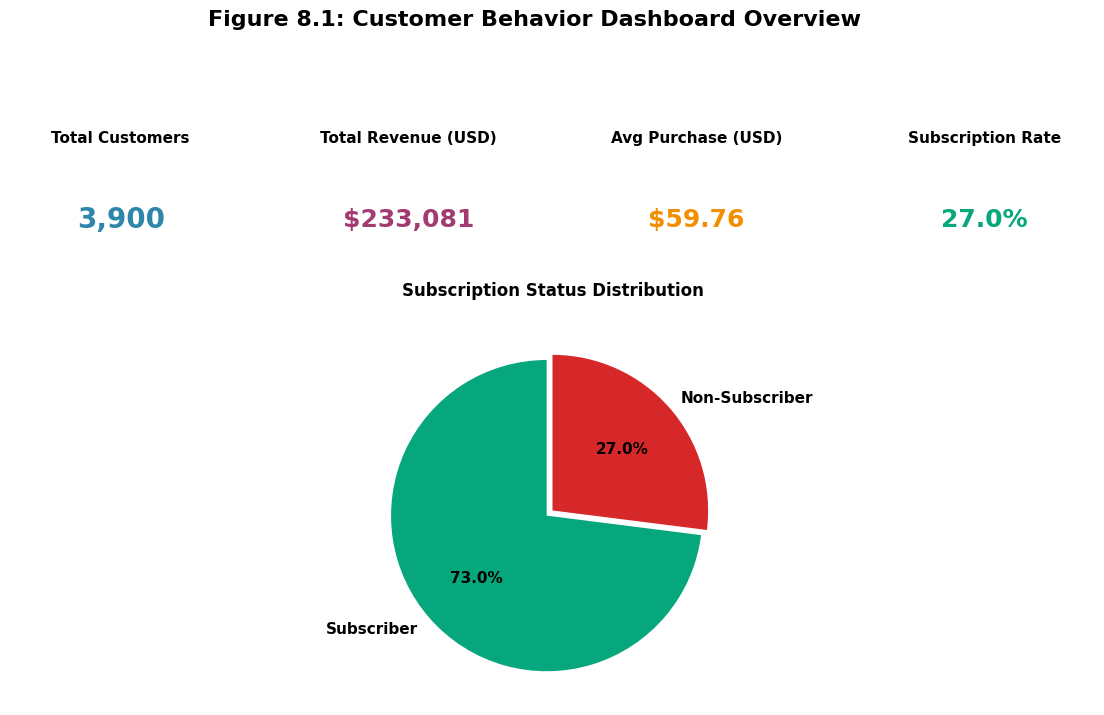

Figure 8.1 generated successfully!


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import numpy as np

# Figure 8.1: Customer Behavior Dashboard with KPIs and Subscription Pie Chart

# Calculate KPIs
total_customers = df.shape[0]
total_revenue = df['purchase_amount'].sum()
avg_purchase = df['purchase_amount'].mean()
subscription_counts = df['subscription_status'].value_counts()
subscription_rate = (subscription_counts.get('Yes', 0) / total_customers) * 100

# Create figure with gridspec for dashboard layout
fig = plt.figure(figsize=(14, 8))
gs = GridSpec(3, 4, figure=fig, hspace=0.4, wspace=0.3)

# Title
fig.suptitle('Figure 8.1: Customer Behavior Dashboard Overview', fontsize=16, fontweight='bold', y=0.98)

# KPI 1: Total Customers
ax1 = fig.add_subplot(gs[0, 0])
ax1.axis('off')
ax1.text(0.5, 0.7, 'Total Customers', ha='center', va='center', fontsize=11, fontweight='bold')
ax1.text(0.5, 0.2, f'{total_customers:,}', ha='center', va='center', fontsize=20, fontweight='bold', color='#2E86AB')

# KPI 2: Total Revenue
ax2 = fig.add_subplot(gs[0, 1])
ax2.axis('off')
ax2.text(0.5, 0.7, 'Total Revenue (USD)', ha='center', va='center', fontsize=11, fontweight='bold')
ax2.text(0.5, 0.2, f'${total_revenue:,.0f}', ha='center', va='center', fontsize=18, fontweight='bold', color='#A23B72')

# KPI 3: Average Purchase
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
ax3.text(0.5, 0.7, 'Avg Purchase (USD)', ha='center', va='center', fontsize=11, fontweight='bold')
ax3.text(0.5, 0.2, f'${avg_purchase:.2f}', ha='center', va='center', fontsize=18, fontweight='bold', color='#F18F01')

# KPI 4: Subscription Rate
ax4 = fig.add_subplot(gs[0, 3])
ax4.axis('off')
ax4.text(0.5, 0.7, 'Subscription Rate', ha='center', va='center', fontsize=11, fontweight='bold')
ax4.text(0.5, 0.2, f'{subscription_rate:.1f}%', ha='center', va='center', fontsize=18, fontweight='bold', color='#06A77D')

# Subscription Pie Chart
ax_pie = fig.add_subplot(gs[1:, 1:3])
colors = ['#06A77D', '#D62828']
explode = (0.05, 0)
wedges, texts, autotexts = ax_pie.pie(subscription_counts, labels=['Subscriber', 'Non-Subscriber'], 
                                        autopct='%1.1f%%', colors=colors, explode=explode,
                                        startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax_pie.set_title('Subscription Status Distribution', fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print("Figure 8.1 generated successfully!")

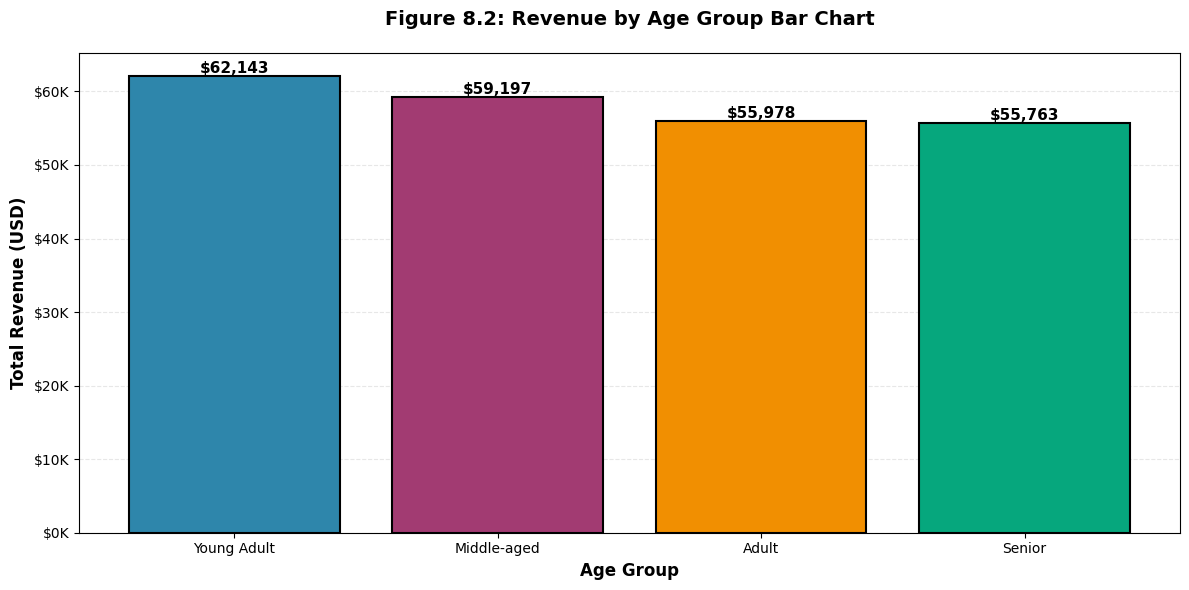


Revenue by Age Group Summary:
  Age Group  Total Revenue  Avg Revenue  Customer Count
Young Adult          62143    60.450389            1028
Middle-aged          59197    60.037525             986
      Adult          55978    59.424628             942
     Senior          55763    59.070975             944

Total Revenue: $233,081.00
Average Revenue per Customer: $59.76


In [6]:
# Figure 8.2: Revenue by Age Group Bar Chart

# Calculate revenue by age group
revenue_by_age = df.groupby('age_group')['purchase_amount'].agg(['sum', 'mean', 'count']).reset_index()
revenue_by_age.columns = ['Age Group', 'Total Revenue', 'Avg Revenue', 'Customer Count']
revenue_by_age = revenue_by_age.sort_values('Total Revenue', ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Create bar chart
bars = ax.bar(revenue_by_age['Age Group'], revenue_by_age['Total Revenue'], 
              color=['#2E86AB', '#A23B72', '#F18F01', '#06A77D'], edgecolor='black', linewidth=1.5)

# Customize chart
ax.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Revenue (USD)', fontsize=12, fontweight='bold')
ax.set_title('Figure 8.2: Revenue by Age Group Bar Chart', fontsize=14, fontweight='bold', pad=20)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:,.0f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Format y-axis to show currency
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nRevenue by Age Group Summary:")
print(revenue_by_age.to_string(index=False))
print(f"\nTotal Revenue: ${revenue_by_age['Total Revenue'].sum():,.2f}")
print(f"Average Revenue per Customer: ${df['purchase_amount'].mean():,.2f}")